## Library and Dataset Preparation

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split


In [37]:
df = pd.read_csv('MedicalAppointmentNoShows_Dataset.csv')

## 1. Initial Exploration and Preprocessing

In [38]:
# a. Class distribution analysis
print("Class Distribution:")
print(df['No-show'].value_counts())

Class Distribution:
No-show
No     88208
Yes    22319
Name: count, dtype: int64


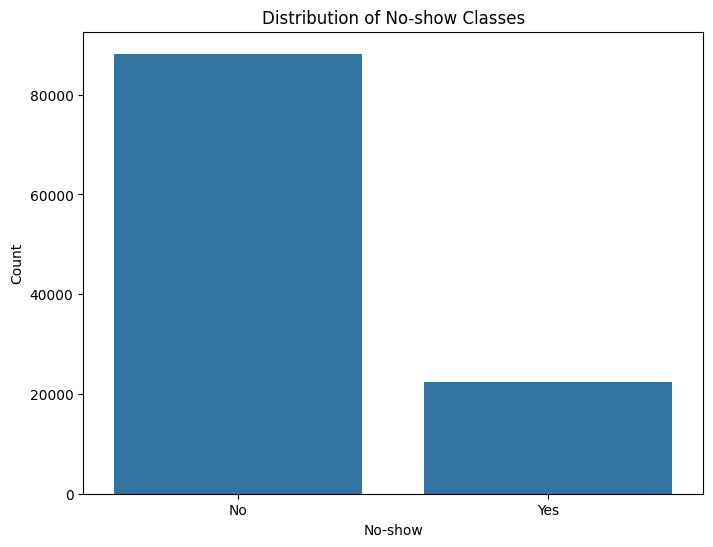

In [39]:
# Bar plot visualization
plt.figure(figsize=(8, 6))
sns.countplot(x='No-show', data=df)
plt.title('Distribution of No-show Classes')
plt.xlabel('No-show')
plt.ylabel('Count')
plt.show()

In [40]:
# b. Normalization of Age column
scaler = MinMaxScaler()
df['Age_normalized'] = scaler.fit_transform(df[['Age']])
print("\nFirst few rows after Age normalization:")
print(df[['Age', 'Age_normalized']].head())


First few rows after Age normalization:
   Age  Age_normalized
0   62        0.543103
1   56        0.491379
2   62        0.543103
3    8        0.077586
4   56        0.491379


## 2. Data Balancing using SMOTE

### Prepare features and target

In [41]:
X = df[['Age_normalized', 'Scholarship', 'Hipertension', 'Diabetes', 
        'Alcoholism', 'Handcap', 'SMS_received']]
y = df['No-show'].map({'No': 0, 'Yes': 1})  

### Before balancing

In [42]:
print("\nClass distribution before balancing:")
print(y.value_counts())


Class distribution before balancing:
No-show
0    88208
1    22319
Name: count, dtype: int64


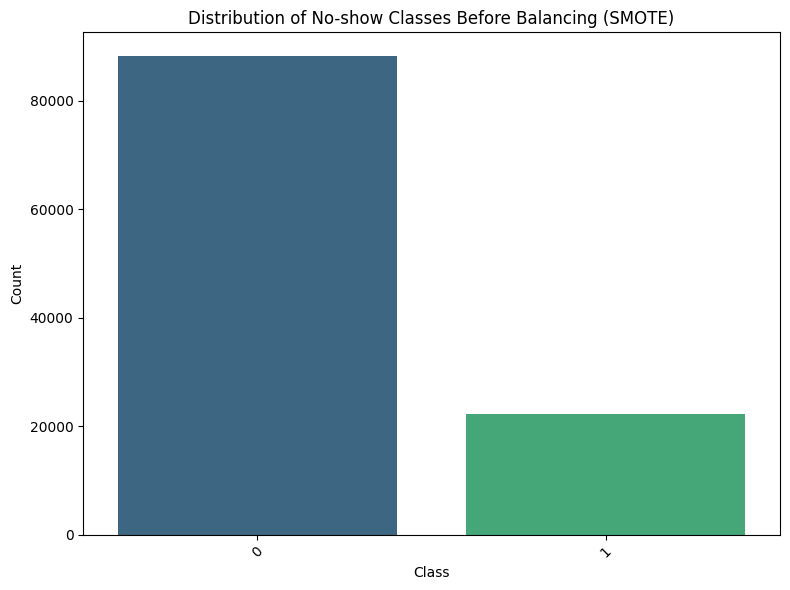

In [43]:
# Visualisasi dengan bar plot
plt.figure(figsize=(8, 6))
sns.countplot(x=y, hue=y, palette='viridis', legend=False)
plt.title('Distribution of No-show Classes Before Balancing (SMOTE)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Apply SMOTE

In [44]:
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

### After balancing

In [45]:
print("\nClass distribution after balancing:")
print(pd.Series(y_balanced).value_counts())


Class distribution after balancing:
No-show
0    88208
1    88208
Name: count, dtype: int64


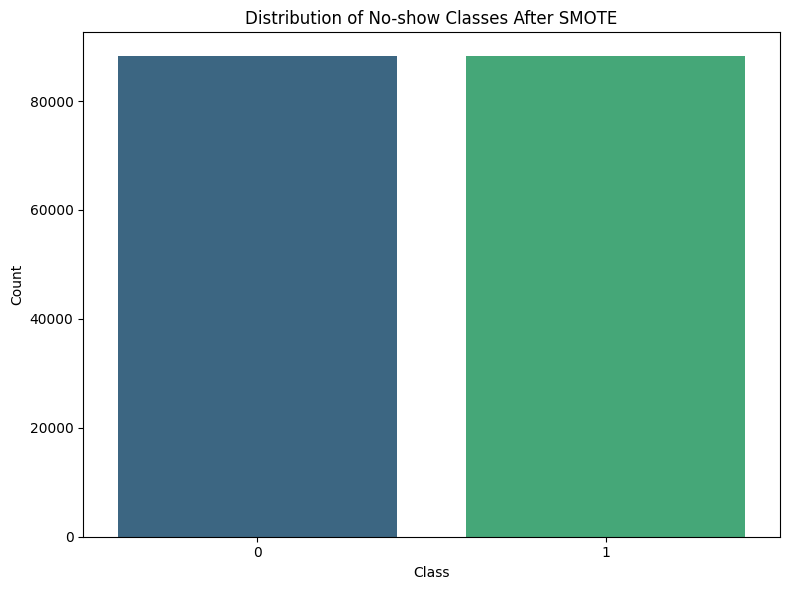

In [46]:
# Visualisasi dengan bar plot
plt.figure(figsize=(8, 6))
sns.countplot(x=pd.Series(y_balanced), hue=pd.Series(y_balanced), palette='viridis', legend=False)
plt.title('Distribution of No-show Classes After SMOTE')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 3. Data Splitting

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_balanced
)

In [49]:
# Verify the split
print("\nTraining set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)
print("\nClass distribution in training set:")
print(pd.Series(y_train).value_counts())
print("\nClass distribution in testing set:")
print(pd.Series(y_test).value_counts())


Training set shape: (141132, 7) (141132,)
Testing set shape: (35284, 7) (35284,)

Class distribution in training set:
No-show
0    70566
1    70566
Name: count, dtype: int64

Class distribution in testing set:
No-show
0    17642
1    17642
Name: count, dtype: int64


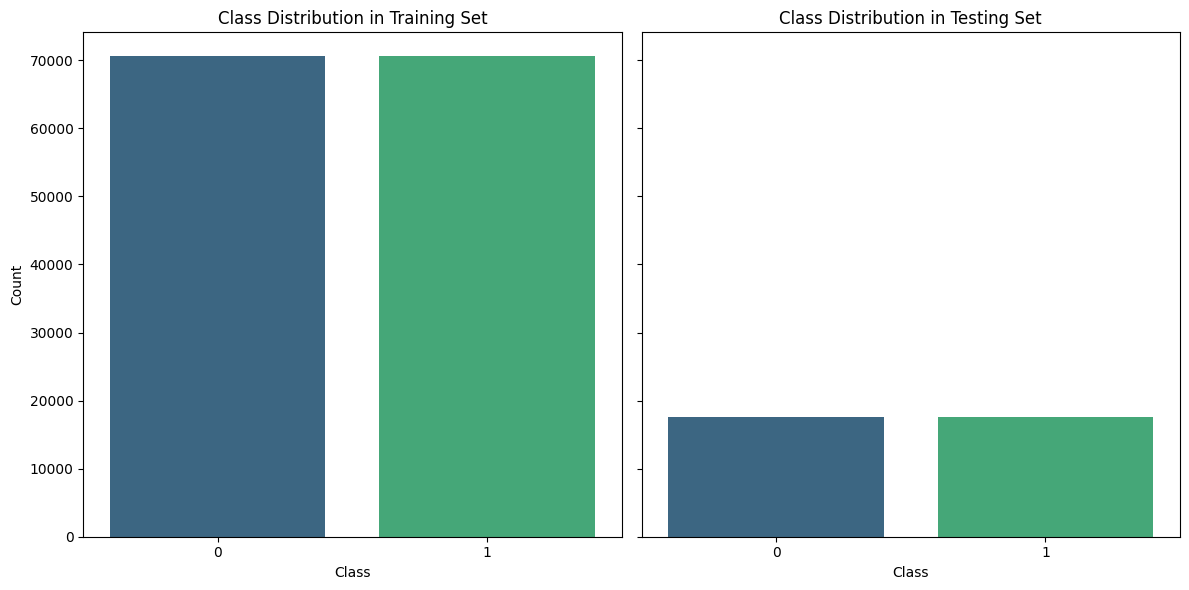

In [50]:
# Visualisasi distribusi kelas untuk training dan testing set
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Plot untuk training set
sns.countplot(x=pd.Series(y_train), hue=pd.Series(y_train), palette='viridis', ax=axes[0], legend=False)
axes[0].set_title('Class Distribution in Training Set')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x')

# Plot untuk testing set
sns.countplot(x=pd.Series(y_test), hue=pd.Series(y_test), palette='viridis', ax=axes[1], legend=False)
axes[1].set_title('Class Distribution in Testing Set')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x')

plt.tight_layout()
plt.show()

## 4. Visualization of class distribution before & after balancing, and after splitting

### Visualization of class distribution before and after SMOTE

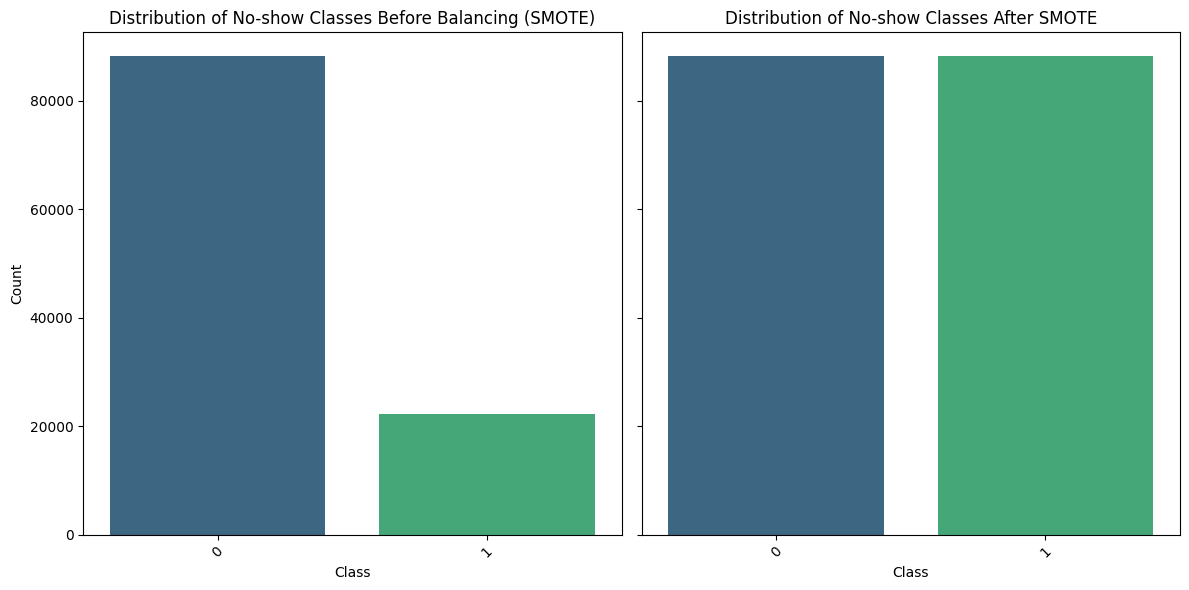

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Plot untuk distribusi sebelum balancing
sns.countplot(x=y, hue=y, palette='viridis', ax=axes[0], legend=False)
axes[0].set_title('Distribution of No-show Classes Before Balancing (SMOTE)')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Plot untuk distribusi sesudah balancing
sns.countplot(x=pd.Series(y_balanced), hue=pd.Series(y_balanced), palette='viridis', ax=axes[1], legend=False)
axes[1].set_title('Distribution of No-show Classes After SMOTE')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Visualization of class distribution for training and testing sets

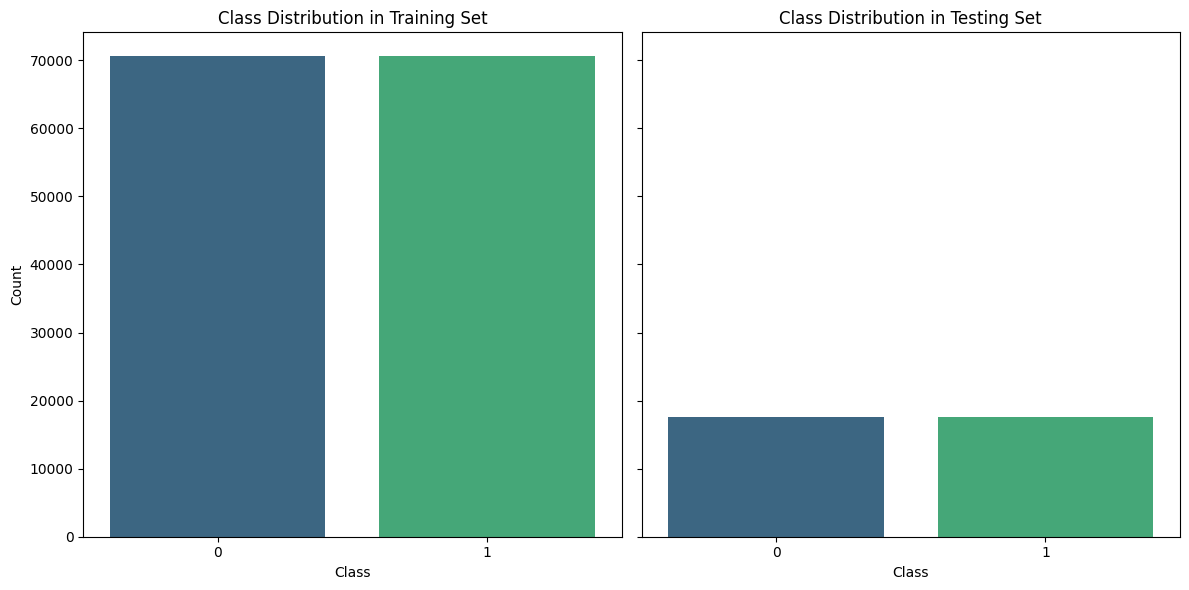

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Plot untuk training set
sns.countplot(x=pd.Series(y_train), hue=pd.Series(y_train), palette='viridis', ax=axes[0], legend=False)
axes[0].set_title('Class Distribution in Training Set')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x')

# Plot untuk testing set
sns.countplot(x=pd.Series(y_test), hue=pd.Series(y_test), palette='viridis', ax=axes[1], legend=False)
axes[1].set_title('Class Distribution in Testing Set')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x')

plt.tight_layout()
plt.show()